# Validate Rebuilt Model Output

Visualize a few NVO scope regions from the rebuilt `20260303_model_results.gpkg`:
- Dataframes with year, coordinates, predicted_dist_m, and crossing year
- Map of each scope region with predicted bank positions 2025–2035

## Setup

In [1]:
import sys
sys.path.insert(0, '../..')

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import src.paths as PATHS

GPKG = PATHS.DATA_DIR / '04_model_outputs/20260303/20260303_model_results.gpkg'

pbp = gpd.read_file(GPKG, layer='predicted_bank_positions')
vvr = gpd.read_file(GPKG, layer='vvr_rates_of_change')
scope = gpd.read_file(GPKG, layer='summary_scope')

scope = scope.rename(columns={'position_id': 'location_id'})
print(f'predicted_bank_positions: {len(pbp):,} rows, {pbp["location_id"].nunique():,} locations')
print(f'vvr_rates_of_change: {len(vvr):,} rows')
print(f'NVO locations: {pbp["is_nvo"].sum() // 11:,}')

predicted_bank_positions: 115,324 rows, 10,484 locations
vvr_rates_of_change: 8,148 rows
NVO locations: 2,427


## Build location_id → predicted_vvr_crossing_year lookup

In [2]:
# Spatial join vvr with scope to get location_id per vvr row
vvr_idx = vvr.copy()
vvr_idx['_idx'] = range(len(vvr_idx))
if vvr_idx.crs != scope.crs:
    vvr_idx = vvr_idx.to_crs(scope.crs)
joined = gpd.sjoin(vvr_idx, scope[['location_id', 'geometry']], how='left', predicate='intersects')
first_match = joined.groupby('_idx').first().reset_index()
crossing_lookup = first_match.set_index('location_id')['predicted_vvr_crossing_year'].to_dict()
print(f'Crossing year lookup: {len(crossing_lookup):,} locations')

Crossing year lookup: 1,021 locations


## Pick a few NVO locations and build dataframes

In [3]:
nvo_locs = pbp[pbp['is_nvo']].drop_duplicates('location_id')['location_id'].tolist()[:5]
print(f'Selected NVO locations: {nvo_locs}')

Selected NVO locations: ['ijssel1_l_10280_10290', 'ijssel1_l_10290_10300', 'ijssel1_l_10300_10310', 'ijssel1_l_10310_10320', 'ijssel1_l_10320_10330']


In [4]:
for loc_id in nvo_locs:
    sub = pbp[pbp['location_id'] == loc_id].sort_values('year').copy()
    sub['x'] = sub.geometry.x
    sub['y'] = sub.geometry.y
    crossing = crossing_lookup.get(loc_id, float('nan'))
    sub['predicted_vvr_crossing_year'] = crossing
    print(f'\n--- {loc_id} ---')
    print(f'predicted_vvr_crossing_year: {crossing}')
    display(sub[['year', 'x', 'y', 'predicted_dist_m', 'velocity_m_per_yr', 'predicted_vvr_crossing_year']])


--- ijssel1_l_10280_10290 ---
predicted_vvr_crossing_year: 2020.0


,year,x,y,predicted_dist_m,velocity_m_per_yr,predicted_vvr_crossing_year
1353,2025,193676.993686,503855.151982,118.674521,0.336968,2020.0
1354,2026,193676.993686,503855.151982,119.011489,0.336968,2020.0
1355,2027,193676.993686,503855.151982,119.348457,0.336968,2020.0
1356,2028,193676.993686,503855.151982,119.685425,0.336968,2020.0
1357,2029,193676.993686,503855.151982,120.022393,0.336968,2020.0
1358,2030,193676.993686,503855.151982,120.359361,0.336968,2020.0
1359,2031,193676.993686,503855.151982,120.696329,0.336968,2020.0
1360,2032,193676.993686,503855.151982,121.033297,0.336968,2020.0
1361,2033,193676.993686,503855.151982,121.370265,0.336968,2020.0
1362,2034,193676.993686,503855.151982,121.707233,0.336968,2020.0



--- ijssel1_l_10290_10300 ---
predicted_vvr_crossing_year: nan


,year,x,y,predicted_dist_m,velocity_m_per_yr,predicted_vvr_crossing_year
1364,2025,193601.040892,503957.221066,121.428571,0.005564,NaN
1365,2026,193601.040892,503957.221066,121.434135,0.005564,NaN
1366,2027,193601.040892,503957.221066,121.439699,0.005564,NaN
1367,2028,193601.040892,503957.221066,121.445263,0.005564,NaN
1368,2029,193601.040892,503957.221066,121.450826,0.005564,NaN
1369,2030,193601.040892,503957.221066,121.456390,0.005564,NaN
1370,2031,193601.040892,503957.221066,121.461954,0.005564,NaN
1371,2032,193601.040892,503957.221066,121.467518,0.005564,NaN
1372,2033,193601.040892,503957.221066,121.473081,0.005564,NaN
1373,2034,193601.040892,503957.221066,121.478645,0.005564,NaN



--- ijssel1_l_10300_10310 ---
predicted_vvr_crossing_year: nan


,year,x,y,predicted_dist_m,velocity_m_per_yr,predicted_vvr_crossing_year
1375,2025,193647.127171,504083.526113,76.612666,0.136312,NaN
1376,2026,193647.127171,504083.526113,76.748977,0.136312,NaN
1377,2027,193647.127171,504083.526113,76.885289,0.136312,NaN
1378,2028,193647.127171,504083.526113,77.021600,0.136312,NaN
1379,2029,193647.127171,504083.526113,77.157912,0.136312,NaN
1380,2030,193647.127171,504083.526113,77.294224,0.136312,NaN
1381,2031,193647.127171,504083.526113,77.430535,0.136312,NaN
1382,2032,193647.127171,504083.526113,77.566847,0.136312,NaN
1383,2033,193647.127171,504083.526113,77.703158,0.136312,NaN
1384,2034,193647.127171,504083.526113,77.839470,0.136312,NaN



--- ijssel1_l_10310_10320 ---
predicted_vvr_crossing_year: nan


,year,x,y,predicted_dist_m,velocity_m_per_yr,predicted_vvr_crossing_year
1397,2025,193634.989744,504185.947323,83.456063,-0.005564,NaN
1398,2026,193634.989744,504185.947323,83.450499,-0.005564,NaN
1399,2027,193634.989744,504185.947323,83.444935,-0.005564,NaN
1400,2028,193634.989744,504185.947323,83.439372,-0.005564,NaN
1401,2029,193634.989744,504185.947323,83.433808,-0.005564,NaN
1402,2030,193634.989744,504185.947323,83.428244,-0.005564,NaN
1403,2031,193634.989744,504185.947323,83.422680,-0.005564,NaN
1404,2032,193634.989744,504185.947323,83.417117,-0.005564,NaN
1405,2033,193634.989744,504185.947323,83.411553,-0.005564,NaN
1406,2034,193634.989744,504185.947323,83.405989,-0.005564,NaN



--- ijssel1_l_10320_10330 ---
predicted_vvr_crossing_year: nan


,year,x,y,predicted_dist_m,velocity_m_per_yr,predicted_vvr_crossing_year
1408,2025,193645.736817,504283.850782,79.116348,-0.180821,NaN
1409,2026,193645.736817,504283.850782,78.935526,-0.180821,NaN
1410,2027,193645.736817,504283.850782,78.754705,-0.180821,NaN
1411,2028,193645.736817,504283.850782,78.573883,-0.180821,NaN
1412,2029,193645.736817,504283.850782,78.393062,-0.180821,NaN
1413,2030,193645.736817,504283.850782,78.212240,-0.180821,NaN
1414,2031,193645.736817,504283.850782,78.031419,-0.180821,NaN
1415,2032,193645.736817,504283.850782,77.850597,-0.180821,NaN
1416,2033,193645.736817,504283.850782,77.669776,-0.180821,NaN
1417,2034,193645.736817,504283.850782,77.488954,-0.180821,NaN


## Visualize each scope region

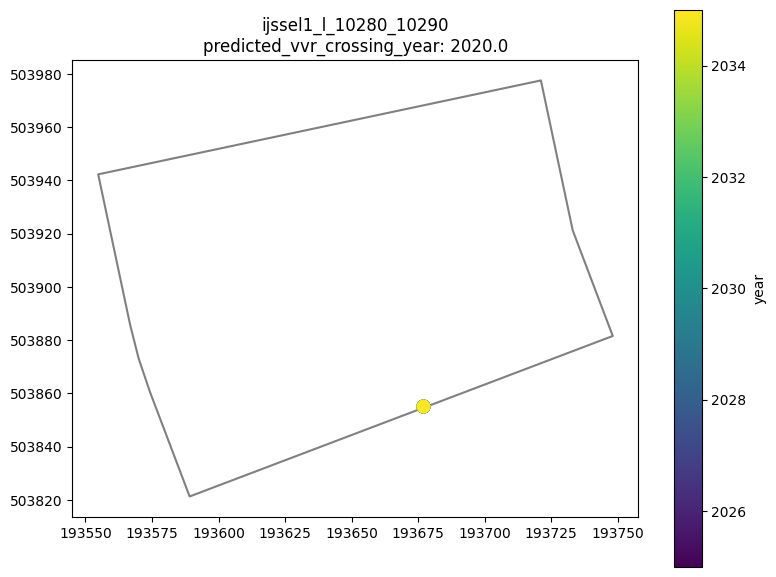

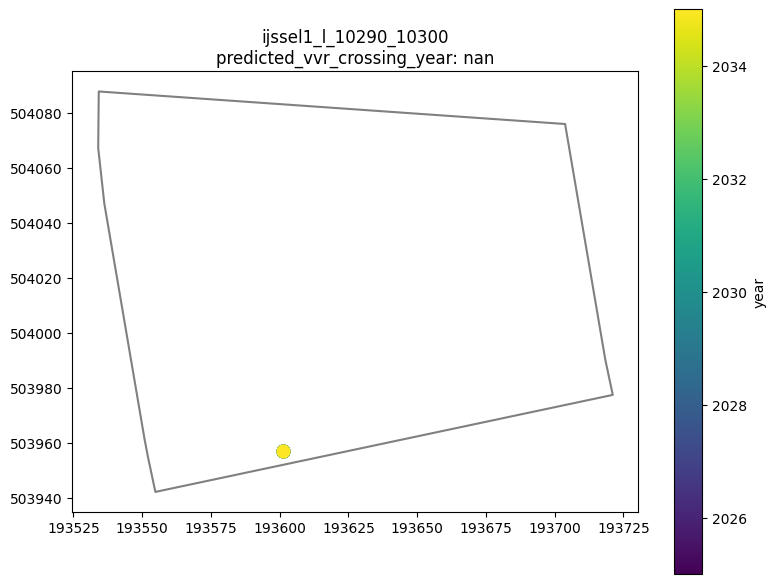

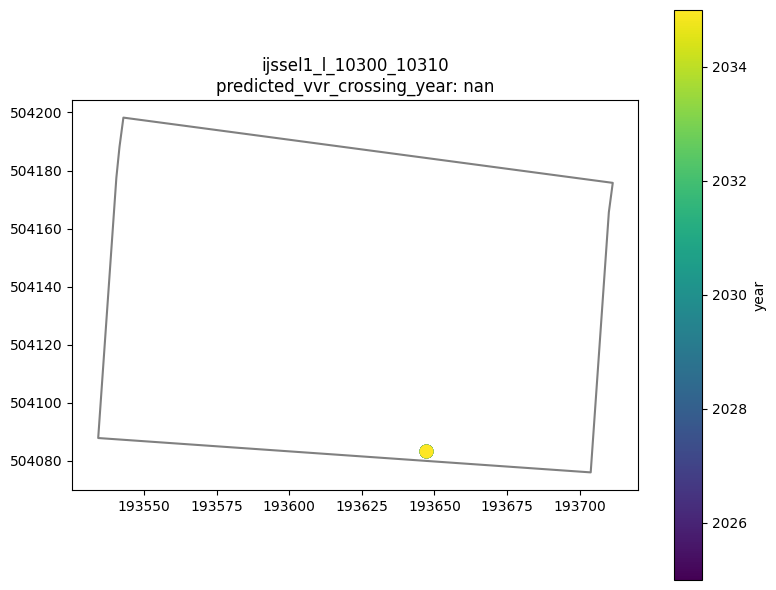

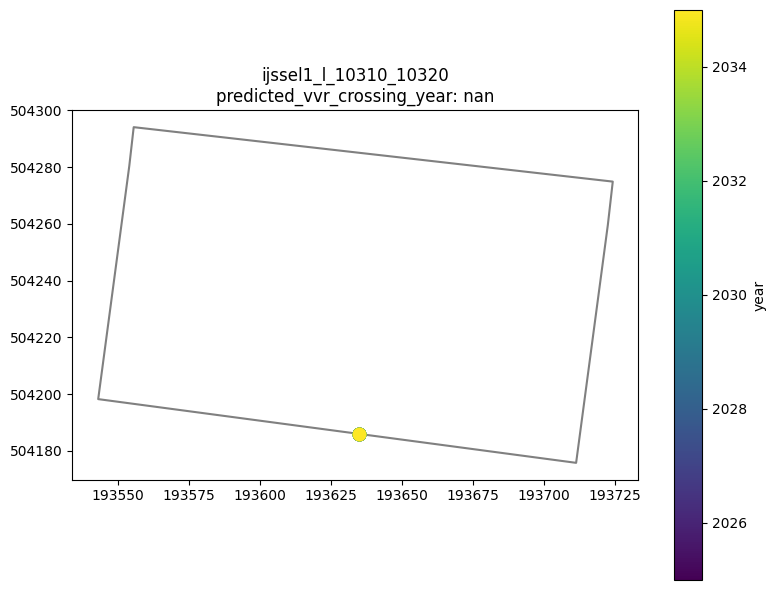

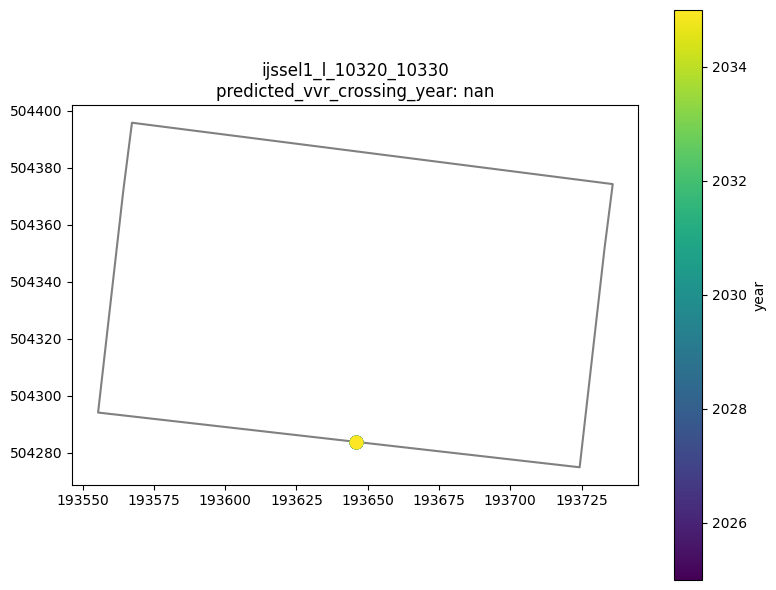

In [5]:
import matplotlib.colors as mcolors
import numpy as np

cmap = plt.cm.viridis
years = sorted(pbp['year'].unique())
norm = mcolors.Normalize(vmin=min(years), vmax=max(years))

for loc_id in nvo_locs:
    scope_geom = scope[scope['location_id'] == loc_id].geometry.iloc[0]
    pts = pbp[pbp['location_id'] == loc_id].sort_values('year')
    crossing = crossing_lookup.get(loc_id, float('nan'))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    gpd.GeoSeries([scope_geom]).plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=1.5)
    for _, row in pts.iterrows():
        ax.scatter(row.geometry.x, row.geometry.y, c=[row['year']], cmap=cmap, norm=norm, s=80, zorder=5)
    ax.set_title(f'{loc_id}\npredicted_vvr_crossing_year: {crossing}')
    ax.set_aspect('equal')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='year')
    plt.tight_layout()
    plt.show()